In [1]:
import pandas as pd

df = pd.read_csv("European_Bank.csv")

print(df.head())
print(df.shape)

   Year  CustomerId   Surname  CreditScore Geography  Gender  Age  Tenure  \
0  2025    15634602  Hargrave          619    France  Female   42       2   
1  2025    15647311      Hill          608     Spain  Female   41       1   
2  2025    15619304      Onio          502    France  Female   42       8   
3  2025    15701354      Boni          699    France  Female   39       1   
4  2025    15737888  Mitchell          850     Spain  Female   43       2   

     Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0       0.00              1          1               1        101348.88   
1   83807.86              1          0               1        112542.58   
2  159660.80              3          1               0        113931.57   
3       0.00              2          0               0         93826.63   
4  125510.82              1          1               1         79084.10   

   Exited  
0       1  
1       0  
2       1  
3       0  
4       0  
(10000, 14)


In [2]:
df.isnull().sum()
df.fillna(df.median(numeric_only=True), inplace=True)

In [3]:
df.drop(
    columns=["CustomerId","Surname"],
    inplace=True
)

df["Year"].nunique()

if "Year" in df.columns:
    df.drop("Year", axis=1, inplace=True)

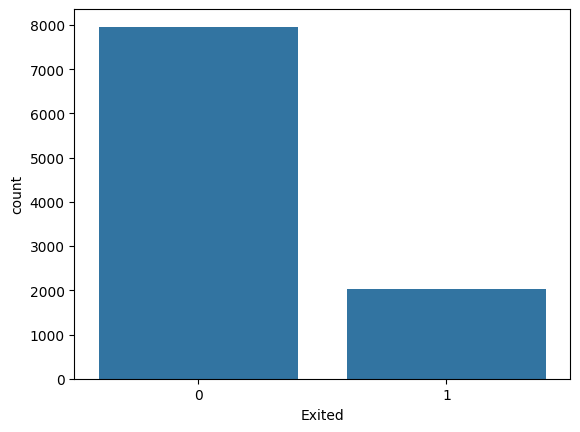

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Exited',data=df)
plt.show()

<Axes: xlabel='Geography', ylabel='Exited'>

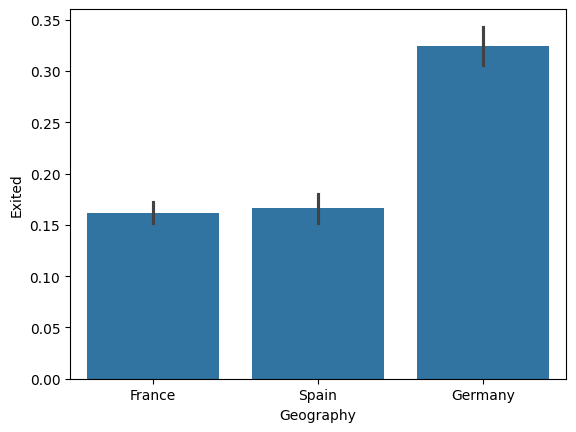

In [5]:
sns.barplot(
    x='Geography',
    y='Exited',
    data=df
)

<Axes: xlabel='Gender', ylabel='Exited'>

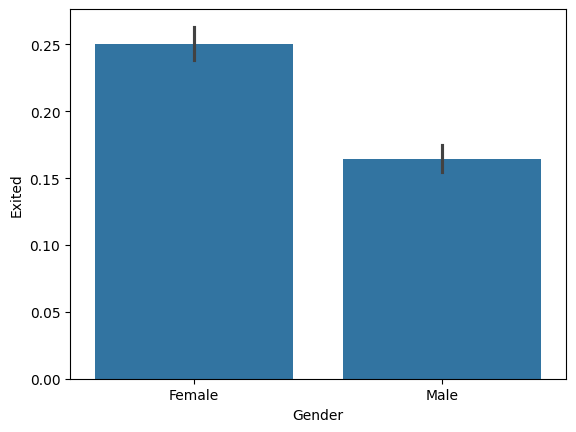

In [6]:
sns.barplot(
    x='Gender',
    y='Exited',
    data=df
)

<Axes: xlabel='Exited', ylabel='Age'>

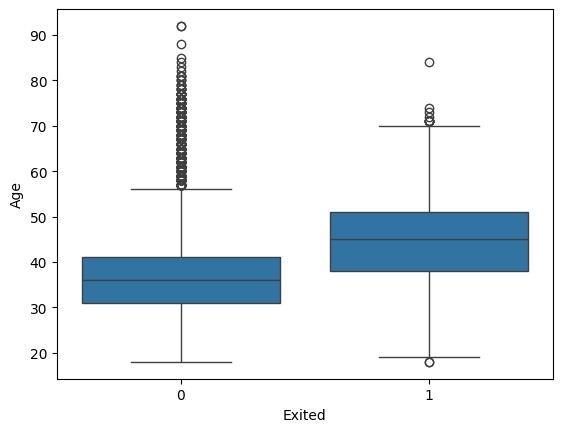

In [7]:
sns.boxplot(
    x='Exited',
    y='Age',
    data=df
)

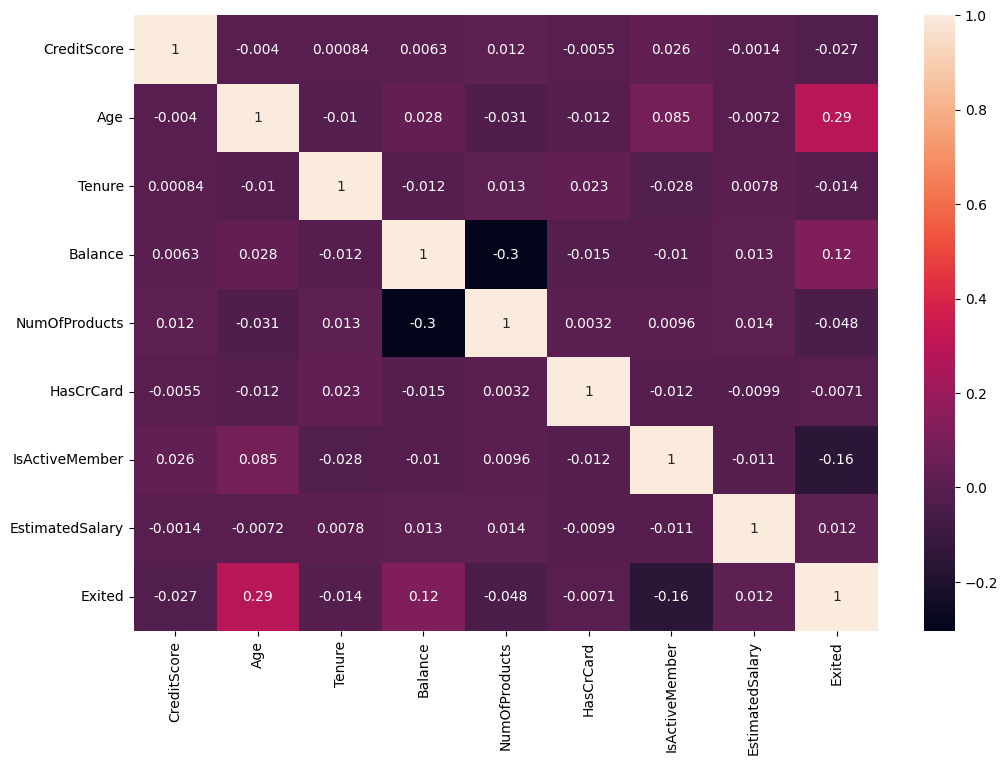

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)
plt.show()

In [9]:
df['BalanceSalaryRatio'] = (
    df['Balance'] /
    (df['EstimatedSalary']+1)
)

In [10]:
df['ProductDensity'] = (
    df['NumOfProducts'] /
    (df['Age']+1)
)

In [11]:
df['EngagementProduct'] = (
    df['IsActiveMember'] *
    df['NumOfProducts']
)

In [12]:
df['AgeTenure'] = (
    df['Age'] *
    df['Tenure']
)

In [13]:
df = pd.get_dummies(
    df,
    columns=['Geography','Gender'],
    drop_first=True
)

In [14]:
X = df.drop('Exited',axis=1)

y = df['Exited']

In [15]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr.predict(X_test_scaled)

In [18]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

In [20]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss'
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(X_test)

In [21]:
from sklearn.metrics import *

print(
    accuracy_score(
        y_test,
        xgb_pred
    )
)

print(
    classification_report(
        y_test,
        xgb_pred
    )
)

0.8535
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1593
           1       0.71      0.48      0.57       407

    accuracy                           0.85      2000
   macro avg       0.79      0.71      0.74      2000
weighted avg       0.84      0.85      0.84      2000



In [22]:
from sklearn.metrics import roc_curve

probs = xgb.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(
    y_test,
    probs
)

In [23]:

from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, probs)
print("ROC-AUC:", auc)

ROC-AUC: 0.8299686435279656


In [24]:
models = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

In [25]:
risk_score = xgb.predict_proba(X_test)[:,1]

In [26]:
def risk_category(x):

    if x<0.30:
        return "Low"

    elif x<0.60:
        return "Medium"

    else:
        return "High"

In [27]:
risk_df = pd.DataFrame()

risk_df["Probability"] = risk_score

risk_df["Risk"] = (
    risk_df["Probability"]
    .apply(risk_category)
)

In [ ]:
import joblib

joblib.dump(rf, "streamlit_app/churn_model.pkl")
joblib.dump(scaler, "streamlit_app/scaler.pkl")
joblib.dump(list(X.columns), "streamlit_app/columns.pkl")

importance.to_csv("streamlit_app/feature_importance.csv",
    index=False
)

NameError: name 'importance' is not defined

In [ ]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':
    xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

In [ ]:
importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

In [ ]:
import os

import joblib
os.makedirs("models", exist_ok=True)

joblib.dump(xgb, "models/churn_model.pkl")

In [ ]:
import joblib

joblib.dump(
    xgb,
    "models/churn_model.pkl"
)